# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [164]:
%load_ext dotenv
%dotenv 

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
import pickle
import os
import shap

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [6]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [7]:
X = fires_dt.drop(columns=['area'])

In [8]:
Y = fires_dt['area']

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [159]:
num_cols = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
cat_cols = ['month', 'day']

preproc_1 = ColumnTransformer(
    transformers=[
        ('num_transform', StandardScaler(), num_cols ),
        ('cat_transform', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary', min_frequency=2), cat_cols), 
    ], remainder='drop'
)
preproc_1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...), ('cat_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [160]:
nt_cols = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi']
trans_cols = ['temp', 'rh', 'wind', 'rain']

pipe_num_qt = Pipeline([
    ('standardizer', StandardScaler()),
    ('transform', QuantileTransformer(n_quantiles=10))
])

preproc_2 = ColumnTransformer(
    transformers=[
        ('num_std', StandardScaler(), nt_cols ),
        ('num_quant', pipe_num_qt, trans_cols ),
        ('cat_transform', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary', min_frequency=2), cat_cols), 
    ], remainder='drop'
)
preproc_2

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_std', ...), ('num_quant', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [163]:
# Split the data
X_rest, X_test, Y_rest, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_validate, Y_train,  Y_validate = train_test_split(X_rest, Y_rest, test_size=0.2, random_state=42)

# Model evaluation function
def evaluate_model(regressor, X_train, Y_train, X_test, Y_test):
    regressor.fit(X_train, Y_train)
    Y_pred_train = regressor.predict(X_train)
    Y_pred_test = regressor.predict(X_test)
    performance_metrics = {
        'r2_train': r2_score(Y_train, Y_pred_train),
        'r2_test': r2_score(Y_test, Y_pred_test),
        'explained_variance_train': explained_variance_score(Y_train, Y_pred_train),
        'explained_variance_train': explained_variance_score(Y_test, Y_pred_test),
        'rmse_train': root_mean_squared_error(Y_train, Y_pred_train),
        'rmse_test': root_mean_squared_error(Y_test, Y_pred_test),
    }
    return performance_metrics

# Pipeline A = preproc1 + baseline

pipe_a = Pipeline([
    ('preprocessing', preproc_1),
    ('regressor', LinearRegression())
])
pipe_a

scoring = ['r2', 'explained_variance', 'neg_root_mean_squared_error']

dict_a = cross_validate(pipe_a, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(dict_a)
pd.DataFrame(dict_a).mean()



/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


fit_time                              0.006438
score_time                            0.002424
test_r2                              -4.466688
train_r2                              0.056826
test_explained_variance              -2.884109
train_explained_variance              0.056826
test_neg_root_mean_squared_error    -54.542493
train_neg_root_mean_squared_error   -60.710142
dtype: float64

In [56]:
# Pipeline B = preproc2 + baseline

pipe_b = Pipeline([
    ('preprocessing', preproc_2),
    ('regressor', LinearRegression())
])
pipe_b

scoring = ['r2', 'explained_variance', 'neg_root_mean_squared_error']

dict_b = cross_validate(pipe_b, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(dict_b)
pd.DataFrame(dict_b).mean()


/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


fit_time                              0.015425
score_time                            0.005231
test_r2                              -4.657849
train_r2                              0.059825
test_explained_variance              -3.062536
train_explained_variance              0.059825
test_neg_root_mean_squared_error    -54.781397
train_neg_root_mean_squared_error   -60.611582
dtype: float64

In [90]:
# Pipeline C = preproc1 + advanced model

pipe_c = Pipeline([
    ('preprocessing', preproc_1),
    ('regressor', ElasticNet(random_state = 42))
])
pipe_c

scoring = ['r2', 'explained_variance', 'neg_root_mean_squared_error']

dict_c = cross_validate(pipe_c, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(dict_c)
pd.DataFrame(dict_c).mean()


/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


fit_time                              0.007229
score_time                            0.002201
test_r2                              -1.591772
train_r2                              0.025467
test_explained_variance              -0.297837
train_explained_variance              0.025467
test_neg_root_mean_squared_error    -49.624144
train_neg_root_mean_squared_error   -61.727116
dtype: float64

In [109]:
# Pipeline D = preproc2 + advanced model

pipe_d = Pipeline([
    ('preprocessing', preproc_2),
    ('regressor', ElasticNet(random_state = 42))
])
pipe_d

scoring = ['r2', 'explained_variance', 'neg_root_mean_squared_error']

dict_d = cross_validate(pipe_d, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(dict_d)
pd.DataFrame(dict_d).mean()
    

/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


fit_time                              0.008202
score_time                            0.003500
test_r2                              -1.359509
train_r2                              0.019190
test_explained_variance              -0.133610
train_explained_variance              0.019190
test_neg_root_mean_squared_error    -49.343073
train_neg_root_mean_squared_error   -61.928722
dtype: float64

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [110]:
# Pipe A

param_grid_a = {
    'regressor__copy_X': [True, False],
    'regressor__fit_intercept': [True, False]
    }

grid_cv_a = GridSearchCV(
    estimator=pipe_a, 
    param_grid=param_grid_a, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_root_mean_squared_error")
grid_cv_a.fit(X_train, Y_train)

res_a = grid_cv_a.cv_results_
res_a = pd.DataFrame(res_a)
res_a.columns

res_a

grid_cv_a.best_params_

/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/productio

{'regressor__copy_X': True, 'regressor__fit_intercept': False}

In [111]:
# Pipe B

param_grid_b = {
    'regressor__copy_X': [True, False],
    'regressor__fit_intercept': [True, False]
    }

grid_cv_b = GridSearchCV(
    estimator=pipe_b, 
    param_grid=param_grid_b, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_root_mean_squared_error")
grid_cv_b.fit(X_train, Y_train)

res_b = grid_cv_b.cv_results_
res_b = pd.DataFrame(res_b)
res_b

print(grid_cv_b.best_params_)

{'regressor__copy_X': True, 'regressor__fit_intercept': True}


/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/productio

In [112]:
# Pipe C

param_grid_c = {
    'regressor__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'regressor__selection': ['cyclic', 'random']
    }

grid_cv_c = GridSearchCV(
    estimator=pipe_c, 
    param_grid=param_grid_c, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_root_mean_squared_error")
grid_cv_c.fit(X_train, Y_train)

res_c = grid_cv_c.cv_results_
res_c = pd.DataFrame(res_c)
res_c.columns

#print(res_c)
grid_cv_c.best_params_
#print(grid_cv_c.best_estimator_)

/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.550e+05, tolerance: 7.234e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.104e+05, tolerance: 8.391e+01
Linear regression models with a zero l1 penalizat

{'regressor__l1_ratio': 0.25, 'regressor__selection': 'cyclic'}

In [114]:
# Pipe D

param_grid_d = {
    'regressor__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'regressor__selection': ['cyclic', 'random']
    }

grid_cv_d = GridSearchCV(
    estimator=pipe_d, 
    param_grid=param_grid_d, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_root_mean_squared_error")
grid_cv_d.fit(X_train, Y_train)

res_d = grid_cv_d.cv_results_
res_d = pd.DataFrame(res_d)
res_d.columns

#res_d
grid_cv_d.best_params_
#print(grid_cv_d.best_estimator_)

/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.561e+05, tolerance: 7.234e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.126e+05, tolerance: 8.391e+01
Linear regression models with a zero l1 penalizat

{'regressor__l1_ratio': 0.75, 'regressor__selection': 'random'}

In [128]:
# Set Hyperparameters form pipes 
pipe_a = Pipeline([
    ('preprocessing', preproc_1),
    ('regressor', LinearRegression(fit_intercept = False))
])
pipe_a

# No changes for pipe_b

pipe_c = Pipeline([
    ('preprocessing', preproc_1),
    ('regressor', ElasticNet(random_state = 42, l1_ratio = 0.25))
])
pipe_c

pipe_d = Pipeline([
    ('preprocessing', preproc_2),
    ('regressor', ElasticNet(random_state = 42, l1_ratio = 0.75, selection = 'random'))
])
pipe_d

# Fit and evaluate models, store results in a df

pipes = [pipe_a, pipe_b, pipe_c, pipe_d]
pipe_names = ['pipe_a', 'pipe_b', 'pipe_c', 'pipe_d']
tuned_model_eval = []
pipe_count = 0

for p in pipes:
    dict_0 = cross_validate(p, X, Y, cv=5, scoring = scoring, return_train_score = True)
    res_0 = pd.DataFrame(dict_0).mean()
    res_0['pipe'] = pipe_names[pipe_count]
    tuned_model_eval.append(res_0)
    pipe_count = pipe_count + 1

pd.DataFrame(tuned_model_eval)

/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/production/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/Users/lisa/Documents/Classes & Workshops/MLF/productio

,fit_time,score_time,test_r2,train_r2,test_explained_variance,train_explained_variance,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,pipe
0,0.005900,0.002489,-4.618786,0.057039,-2.976941,0.057039,-54.680478,-60.704502,pipe_a
1,0.004505,0.002955,-4.657849,0.059825,-3.062536,0.059825,-54.781397,-60.611582,pipe_b
2,0.002917,0.001772,-1.558617,0.024201,-0.262581,0.024201,-49.516247,-61.768952,pipe_c
3,0.004999,0.002619,-1.379649,0.021776,-0.162481,0.021776,-49.466819,-61.842896,pipe_d


# Evaluate

+ Which model has the best performance?

The model in pipe_d (ElasticNet, with l1_ration = 0.75 and selection = "random", with 3-way variable scaling) appears to have the best performance in test because it has the lowest RMSE. However, other models particularly pipe_a dnd pipe_b (Linear models), preform better in training (across all metrics) and only show a small decrease in performance at test for RMSE

# Export

+ Save the best performing model to a pickle file.

In [131]:
os.makedirs("./models", exist_ok=True)
with open('./models/forest_fires_grid_search.pkl', 'wb') as f:
    pickle.dump(grid_cv_d.best_estimator_, f)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [167]:
data_transform

array([[ 0.60189977,  0.61006044, -0.89853571, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.03844246,  0.61006044,  0.92659138, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.47498515,  1.46674105,  0.2629088 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.16535708, -0.24662018,  0.08039609, ...,  0.        ,
         0.        ,  0.        ],
       [-1.14427099, -0.24662018, -1.47925797, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.60189977, -1.10330079,  0.37905326, ...,  1.        ,
         0.        ,  0.        ]], shape=(104, 29))

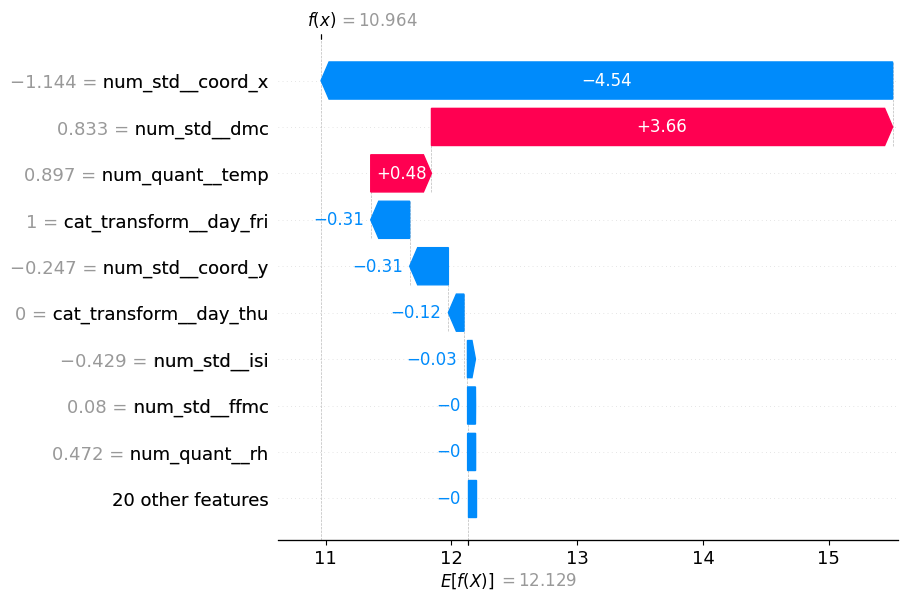

In [175]:
pipe_d.fit(X_train, Y_train)
data_transform = pipe_d.named_steps['preprocessing'].transform(X_test)
pipe_d.named_steps['regressor']

explainer = shap.LinearExplainer(
    pipe_d.named_steps['regressor'], 
    data_transform,
    feature_names = pipe_d.named_steps['preprocessing'].get_feature_names_out())

shap_values = explainer(data_transform)

shap.plots.waterfall(shap_values[10])

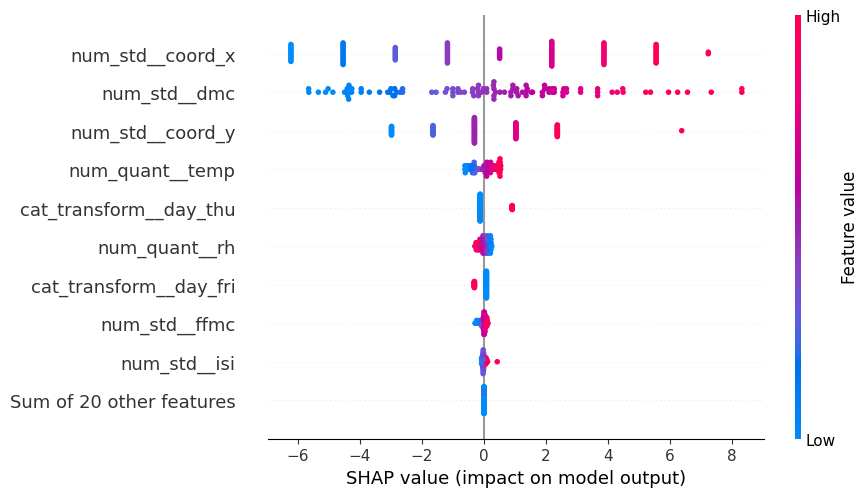

In [176]:

shap.plots.beeswarm(shap_values)

For the individual value, the x coordinate, DMC and temperature were the most important features.

For the entire training set, the x and y coordinates, DMC and temperature were the most important features. The least important features are month, day (at least for most of the week), wind, train, and DC.

If I were to remove features, I would start with the leas important ones, particularly month, and day of the week. I would test these by running model comparisons to see if removing the features improves model fit or not.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.